In [1]:
from Validators.keypoint_validator import *
from Validators.corpus_validator import *

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

CORPUS_PATH = r'C:\Users\Oscar Strong\Desktop\finalProgect\Validated_SubCorpus'
corpus = CorpusValidator(CORPUS_PATH)

fixed_data     = corpus.get_all_hand_distances(midpoint=0.5)
adaptive_data  = corpus.get_all_adaptive_distances()

print(f'Files loaded: {len(fixed_data)}')

22 files found in corpus
Files loaded: 22


In [2]:
def extract_flat_distances(data_dict, source='fixed'):
    """
    Flatten corpus distance dicts into four arrays:
        left_vals, right_vals  — one value per visible frame
    source: 'fixed' or 'adaptive'
    """
    left_vals, right_vals = [], []
    for filepath, payload in data_dict.items():
        frames = payload['distances'] if source == 'adaptive' else payload
        for frame in frames:
            l = frame.get('left')
            r = frame.get('right')
            if l is not None: left_vals.append(l)
            if r is not None: right_vals.append(r)
    return np.array(left_vals), np.array(right_vals)


def extract_per_file_distances(data_dict, source='fixed'):
    """
    Returns a list of (filepath_label, left_series, right_series) tuples.
    Series are lists with None preserved for missing frames.
    """
    out = []
    for filepath, payload in data_dict.items():
        frames = payload['distances'] if source == 'adaptive' else payload
        label = filepath.split('\\')[-1].replace('.json', '')
        left_series  = [f.get('left')  for f in frames]
        right_series = [f.get('right') for f in frames]
        out.append((label, left_series, right_series))
    return out


def series_to_plot(series):
    """Split a series with Nones into plottable (x, y) segments."""
    xs, ys = [], []
    for i, v in enumerate(series):
        if v is not None:
            xs.append(i); ys.append(v)
    return xs, ys


# pull flat arrays for both modes
fix_left,  fix_right  = extract_flat_distances(fixed_data,    source='fixed')
adp_left,  adp_right  = extract_flat_distances(adaptive_data, source='adaptive')

# per-file adaptive midpoints
adaptive_midpoints = {
    fp.split('\\')[-1].replace('.json', ''): v['adaptive_midpoint']
    for fp, v in adaptive_data.items()
}

print('Fixed   — left frames:', len(fix_left),  ' right frames:', len(fix_right))
print('Adaptive— left frames:', len(adp_left),  ' right frames:', len(adp_right))

Fixed   — left frames: 1355  right frames: 1460
Adaptive— left frames: 1355  right frames: 1460


## Corpus-Wide Distance Distributions (Fixed vs Adaptive Midpoint)

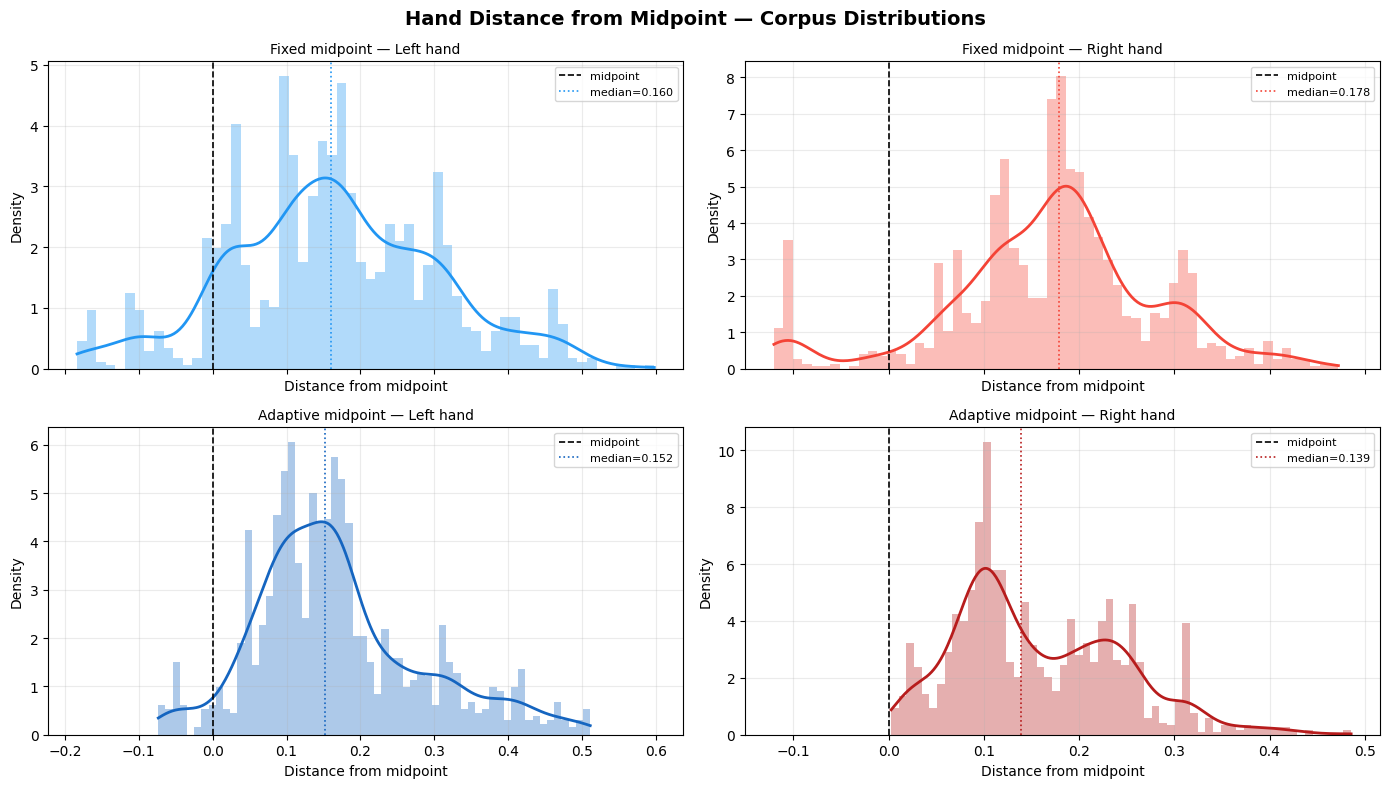

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex='col')
fig.suptitle('Hand Distance from Midpoint — Corpus Distributions', fontsize=14, fontweight='bold')

plot_cfg = [
    (axes[0, 0], fix_left,   'Fixed midpoint — Left hand',   '#2196F3'),
    (axes[0, 1], fix_right,  'Fixed midpoint — Right hand',  '#F44336'),
    (axes[1, 0], adp_left,   'Adaptive midpoint — Left hand',  '#1565C0'),
    (axes[1, 1], adp_right,  'Adaptive midpoint — Right hand', '#B71C1C'),
]

for ax, vals, title, colour in plot_cfg:
    ax.hist(vals, bins=60, density=True, alpha=0.35, color=colour)
    if len(vals) > 1:
        kde = gaussian_kde(vals, bw_method='scott')
        xs  = np.linspace(vals.min(), vals.max(), 400)
        ax.plot(xs, kde(xs), color=colour, linewidth=2)
    ax.axvline(0,            color='black', linewidth=1.2, linestyle='--', label='midpoint')
    ax.axvline(np.median(vals), color=colour, linewidth=1.2, linestyle=':',
               label=f'median={np.median(vals):.3f}')
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Density')
    ax.set_xlabel('Distance from midpoint')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## Fixed vs Adaptive Overlay (left and right combined)

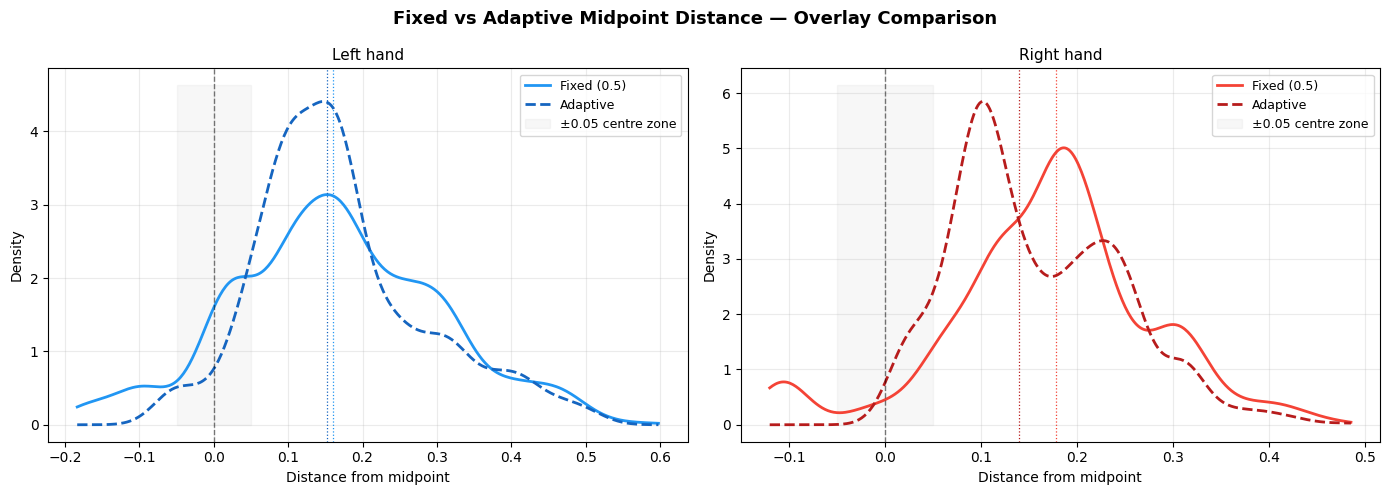

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fixed vs Adaptive Midpoint Distance — Overlay Comparison', fontsize=13, fontweight='bold')

for ax, fix, adp, label, c_fix, c_adp in [
    (axes[0], fix_left,  adp_left,  'Left hand',  '#2196F3', '#1565C0'),
    (axes[1], fix_right, adp_right, 'Right hand', '#F44336', '#B71C1C'),
]:
    for vals, colour, name, ls in [
        (fix, c_fix, 'Fixed (0.5)', '-'),
        (adp, c_adp, 'Adaptive',    '--'),
    ]:
        kde = gaussian_kde(vals, bw_method='scott')
        xs  = np.linspace(min(fix.min(), adp.min()), max(fix.max(), adp.max()), 400)
        ax.plot(xs, kde(xs), color=colour, linewidth=2, linestyle=ls, label=name)
        ax.axvline(np.median(vals), color=colour, linewidth=0.9, linestyle=':')

    ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1],
                     -0.05, 0.05, alpha=0.06, color='grey', label='±0.05 centre zone')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Distance from midpoint')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## Per-File Adaptive Midpoints

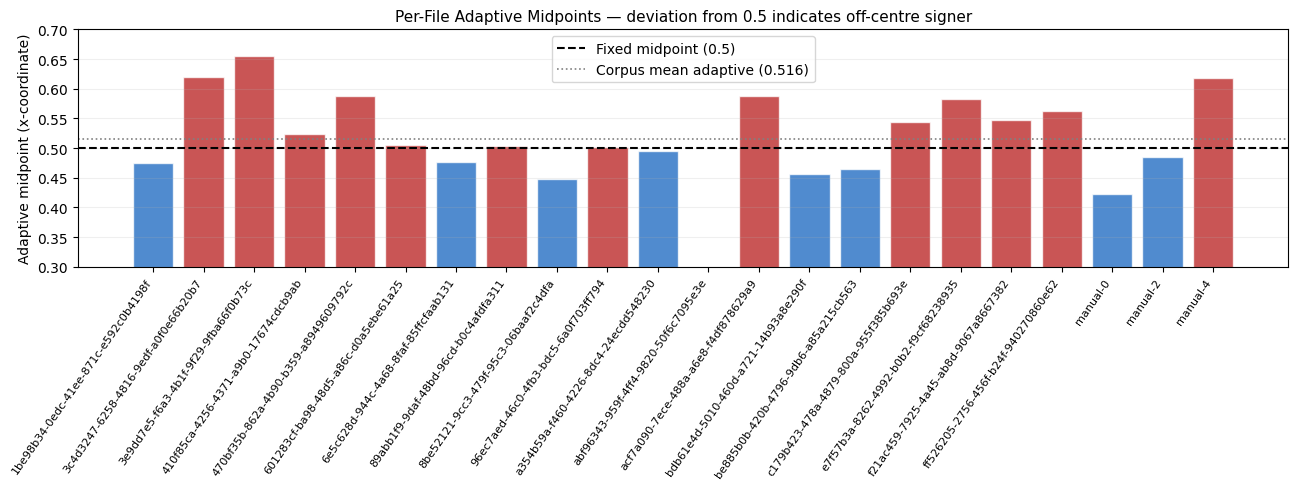

In [5]:
labels = list(adaptive_midpoints.keys())
mids   = [adaptive_midpoints[l] for l in labels]
colours = ['#1565C0' if m < 0.5 else '#B71C1C' for m in mids]

fig, ax = plt.subplots(figsize=(max(10, len(labels) * 0.6), 5))
bars = ax.bar(range(len(labels)), mids, color=colours, alpha=0.75, edgecolor='white')
ax.axhline(0.5, color='black', linewidth=1.5, linestyle='--', label='Fixed midpoint (0.5)')
ax.axhline(np.mean(mids), color='grey', linewidth=1.2, linestyle=':',
           label=f'Corpus mean adaptive ({np.mean(mids):.3f})')

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=55, ha='right', fontsize=8)
ax.set_ylabel('Adaptive midpoint (x-coordinate)')
ax.set_title('Per-File Adaptive Midpoints — deviation from 0.5 indicates off-centre signer', fontsize=11)
ax.set_ylim(0.3, 0.7)
ax.legend()
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

## Per-File Distance Time Series (Fixed Midpoint)

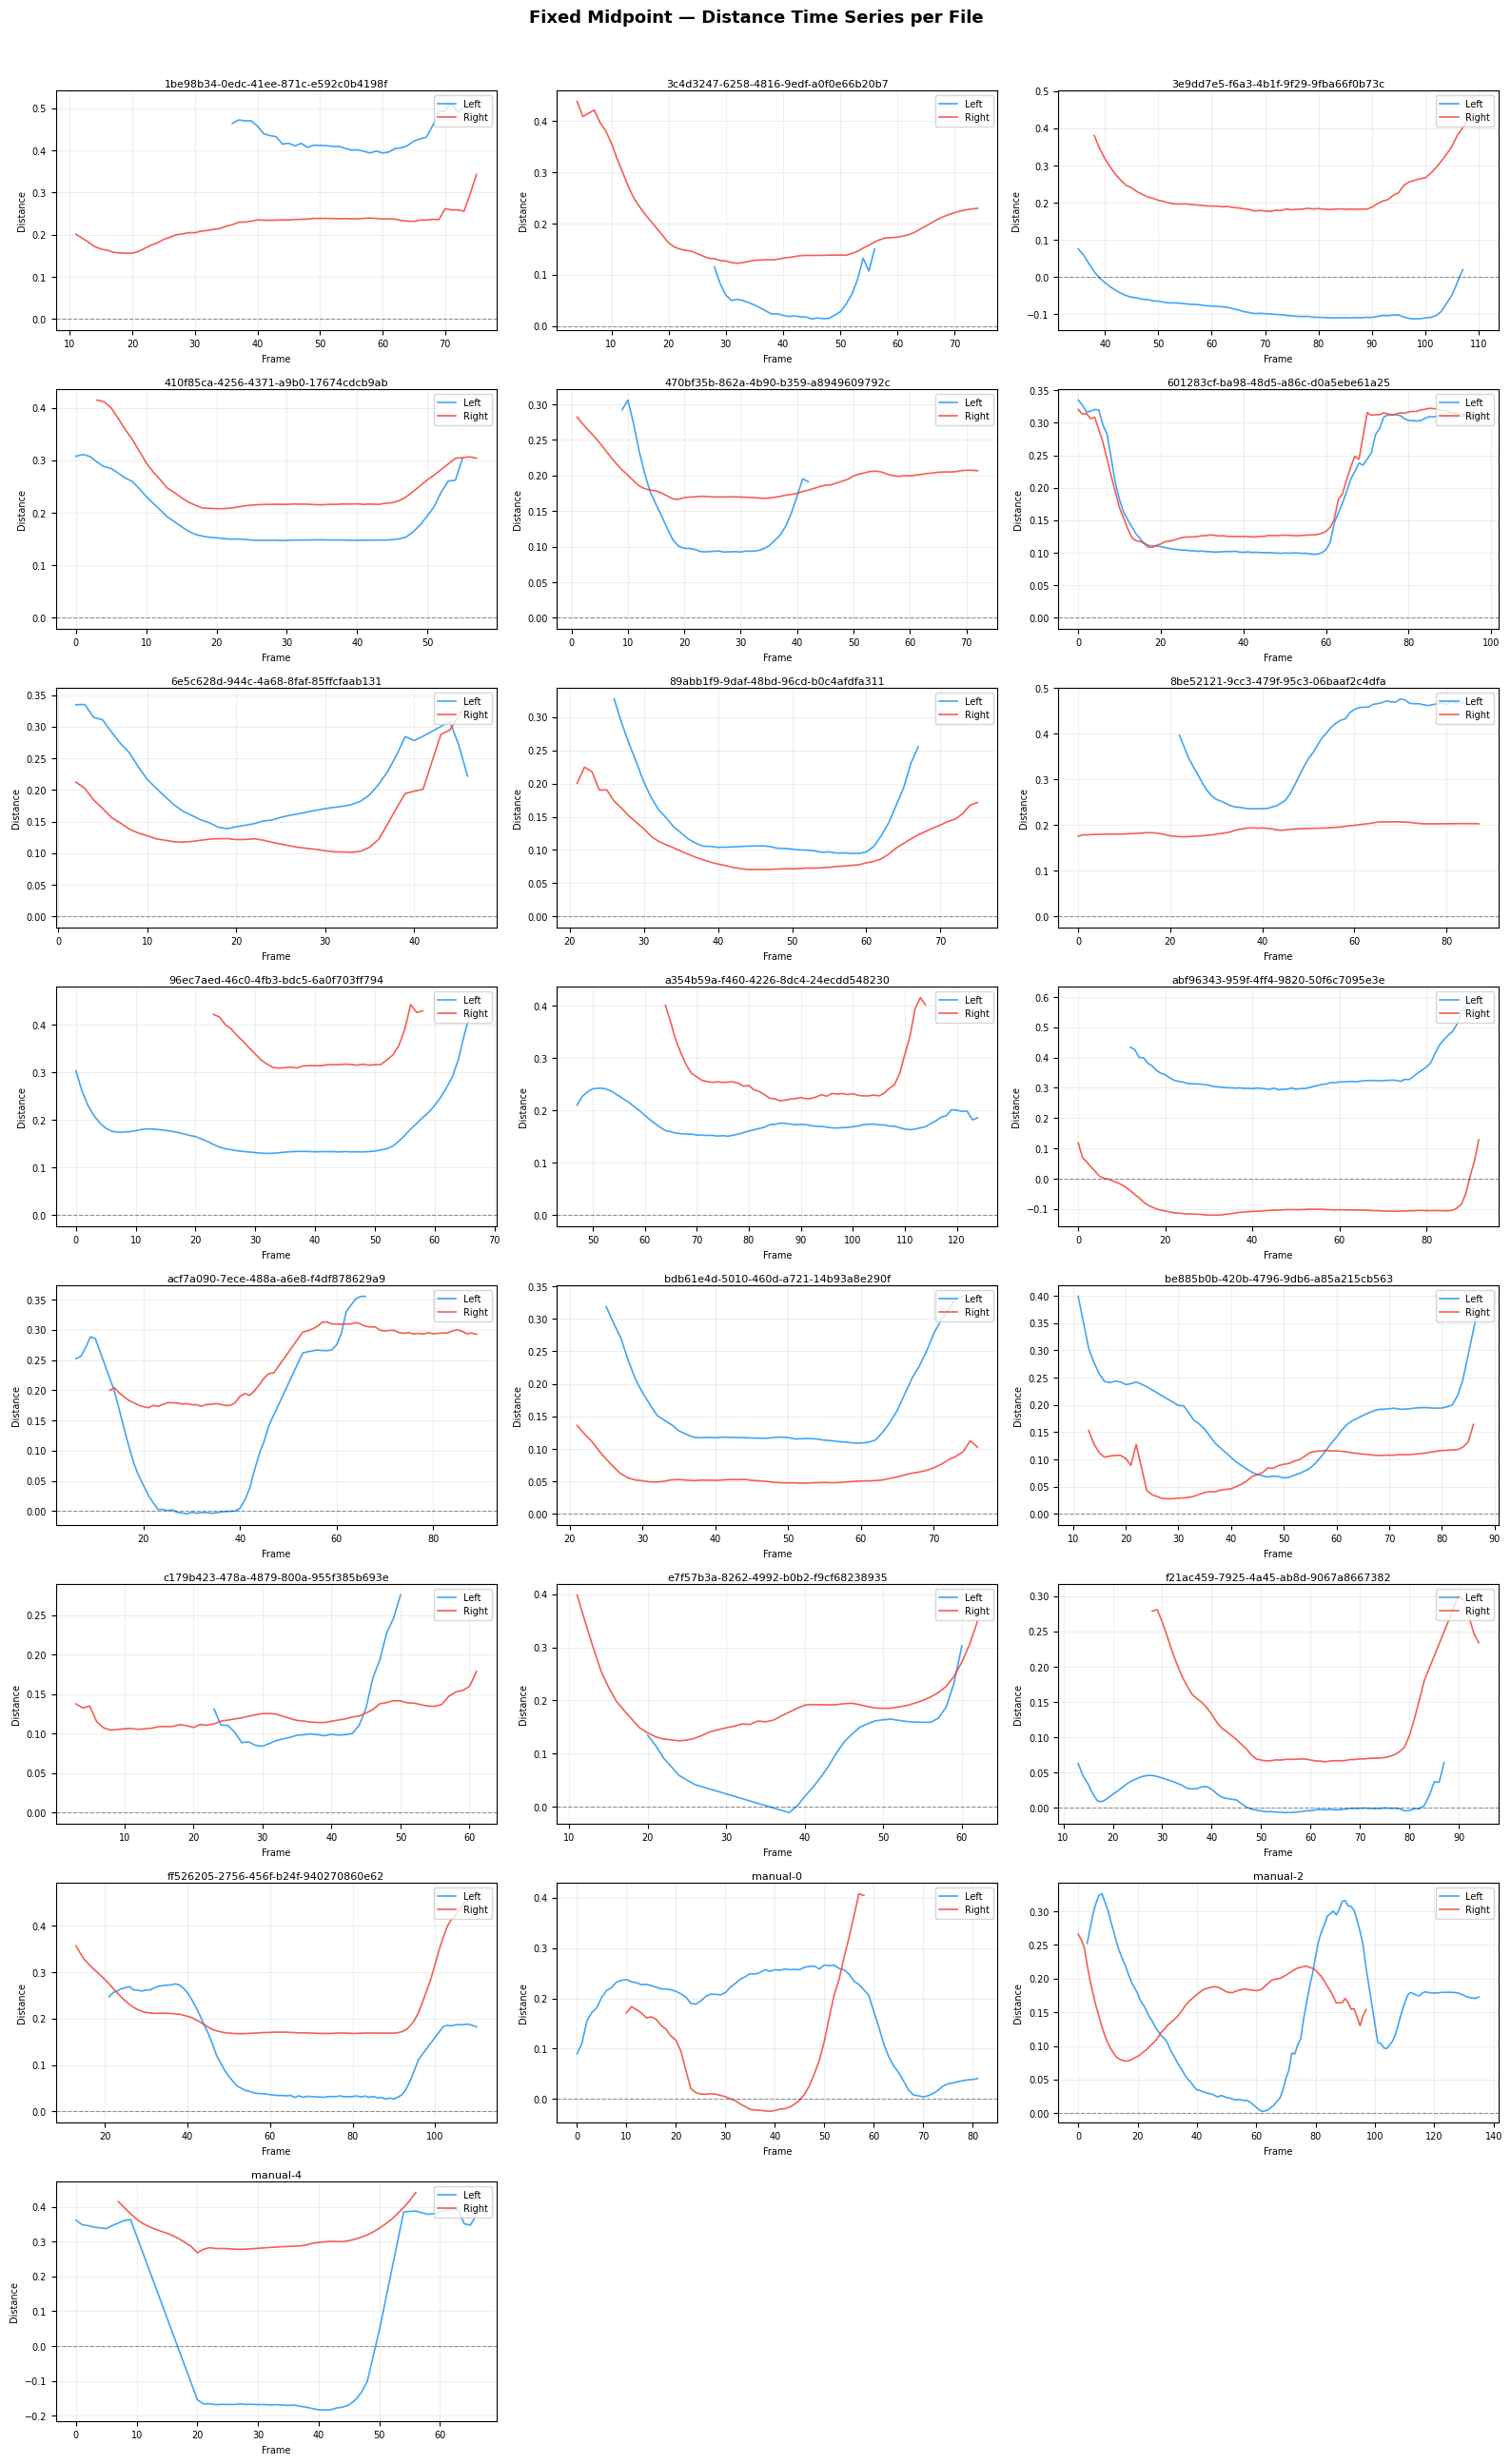

In [6]:
per_file_fixed = extract_per_file_distances(fixed_data, source='fixed')
n_files = len(per_file_fixed)
n_cols  = 3
n_rows  = int(np.ceil(n_files / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.2))
fig.suptitle('Fixed Midpoint — Distance Time Series per File', fontsize=13, fontweight='bold', y=1.01)
axes_flat = axes.flatten() if n_files > 1 else [axes]

for idx, (label, left_s, right_s) in enumerate(per_file_fixed):
    ax = axes_flat[idx]
    lx, ly = series_to_plot(left_s)
    rx, ry = series_to_plot(right_s)
    if lx: ax.plot(lx, ly, color='#2196F3', linewidth=1.2, alpha=0.85, label='Left')
    if rx: ax.plot(rx, ry, color='#F44336', linewidth=1.2, alpha=0.85, label='Right')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.set_title(label, fontsize=8, pad=3)
    ax.set_xlabel('Frame', fontsize=7)
    ax.set_ylabel('Distance', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=7, loc='upper right')

for idx in range(n_files, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

## Per-File Distance Time Series (Adaptive Midpoint)

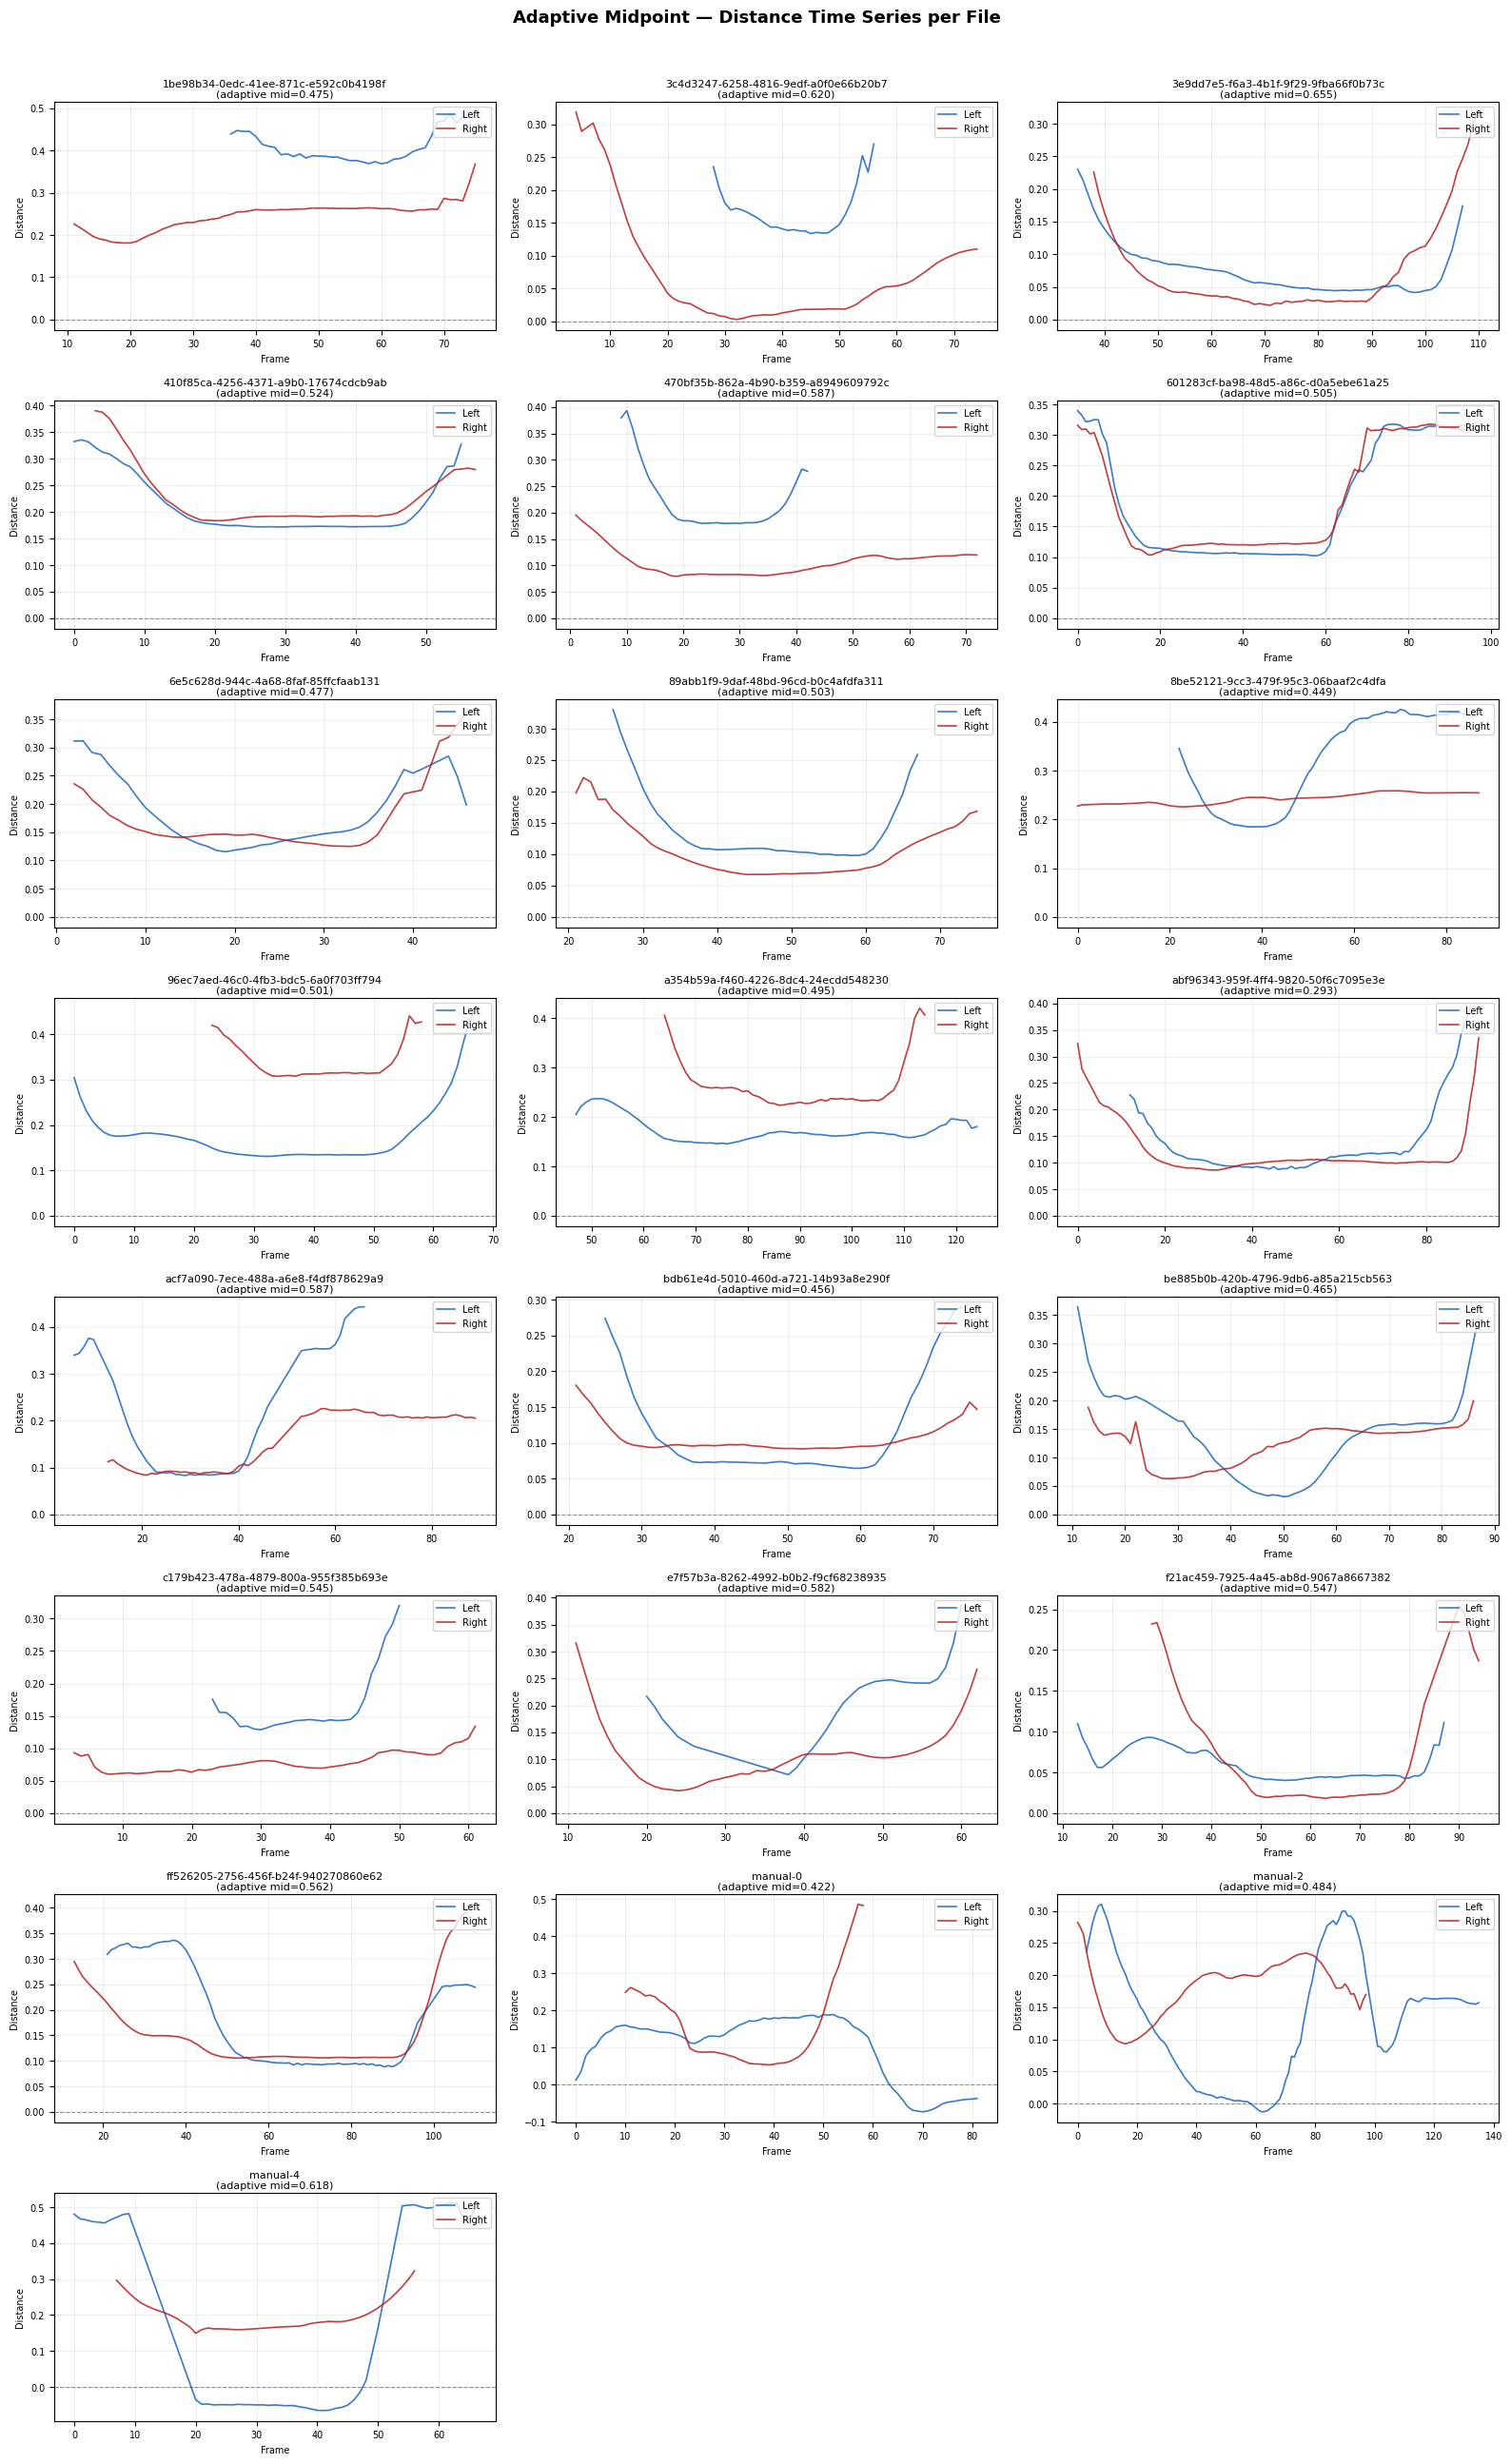

In [7]:
per_file_adp = extract_per_file_distances(adaptive_data, source='adaptive')
n_files = len(per_file_adp)
n_cols  = 3
n_rows  = int(np.ceil(n_files / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.2))
fig.suptitle('Adaptive Midpoint — Distance Time Series per File', fontsize=13, fontweight='bold', y=1.01)
axes_flat = axes.flatten() if n_files > 1 else [axes]

for idx, (label, left_s, right_s) in enumerate(per_file_adp):
    ax = axes_flat[idx]
    mid_val = adaptive_midpoints.get(label, 0.5)
    lx, ly = series_to_plot(left_s)
    rx, ry = series_to_plot(right_s)
    if lx: ax.plot(lx, ly, color='#1565C0', linewidth=1.2, alpha=0.85, label='Left')
    if rx: ax.plot(rx, ry, color='#B71C1C', linewidth=1.2, alpha=0.85, label='Right')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.set_title(f"{label}\n(adaptive mid={mid_val:.3f})", fontsize=8, pad=3)
    ax.set_xlabel('Frame', fontsize=7)
    ax.set_ylabel('Distance', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=7, loc='upper right')

for idx in range(n_files, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [8]:
def stats_row(label, arr):
    return {
        'Series':  label,
        'N':       len(arr),
        'Mean':    round(float(arr.mean()), 4),
        'Median':  round(float(np.median(arr)), 4),
        'Std':     round(float(arr.std()),  4),
        'Min':     round(float(arr.min()),  4),
        'Max':     round(float(arr.max()),  4),
        '% negative': round(float((arr < 0).mean() * 100), 2),
    }

import pandas as pd
summary = pd.DataFrame([
    stats_row('Fixed   — Left',    fix_left),
    stats_row('Fixed   — Right',   fix_right),
    stats_row('Adaptive — Left',   adp_left),
    stats_row('Adaptive — Right',  adp_right),
])
summary.set_index('Series', inplace=True)
print('% negative = fraction of frames where hand is on the WRONG side of midpoint')
summary

% negative = fraction of frames where hand is on the WRONG side of midpoint


,N,Mean,Median,Std,Min,Max,% negative
Series,,,,,,,
Fixed — Left,1355,0.1636,0.1604,0.1407,-0.1837,0.5979,10.70
Fixed — Right,1460,0.1706,0.1785,0.1083,-0.1205,0.4724,6.64
Adaptive — Left,1355,0.1694,0.1520,0.1145,-0.0737,0.5113,3.99
Adaptive — Right,1460,0.1573,0.1391,0.0873,0.0027,0.4857,0.00


In [9]:
from Validators.corpus_validator import *
corpus = CorpusValidator(r"C:\Users\Oscar Strong\Documents\GitHub\BSL-keypoint-processing\KeypointCorpus_unprocessed")


309 files found in corpus


In [18]:
## Abnormal Distance Clustering Analysis
# Analyze the lengths of consecutive flagged abnormal frames across the corpus

def find_consecutive_clusters(flagged_frames):
    """
    Given a list of flagged frame indices, find groups of consecutive frames.
    Returns the length of each consecutive group.
    
    Example: [2, 3, 4, 50, 51] → [3, 2]
    """
    if not flagged_frames:
        return []
    
    flagged_frames = sorted(set(flagged_frames))  # unique and sorted
    clusters = []
    current_cluster_start = flagged_frames[0]
    current_cluster_length = 1
    
    for i in range(1, len(flagged_frames)):
        if flagged_frames[i] == flagged_frames[i-1] + 1:
            # consecutive
            current_cluster_length += 1
        else:
            # gap found, save cluster and start new one
            clusters.append(current_cluster_length)
            current_cluster_start = flagged_frames[i]
            current_cluster_length = 1
    
    # Don't forget the last cluster
    clusters.append(current_cluster_length)
    return clusters


# Collect all cluster lengths from the entire corpus
all_cluster_lengths = []
corpus_results = {}

for validator in corpus.validators:
    filepath = validator.filepath
    basename = filepath.split('\\')[-1].replace('.json', '')
    
    try:
        flags = validator.flagAbnormalDistances(outlier_boundry=-0.1)
        left_flags = flags[0]
        right_flags = flags[1]
    except Exception as e:
        print("error while finding flags:", e)
        left_flags = []
        right_flags = []
    
    # Find consecutive clusters for each hand
    left_clusters = find_consecutive_clusters(left_flags)
    right_clusters = find_consecutive_clusters(right_flags)
    
    
    all_cluster_lengths.extend(left_clusters)
    all_cluster_lengths.extend(right_clusters)
    
    corpus_results[basename] = {
        'filepath': filepath,  # Store the full path!
        'left_flagged_frames': left_flags,
        'right_flagged_frames': right_flags,
        'left_cluster_lengths': left_clusters,
        'right_cluster_lengths': right_clusters,
        'total_clusters': len(left_clusters) + len(right_clusters)
    }

print(f"Total abnormal clusters found: {len(all_cluster_lengths)}")
print(f"Cluster lengths range: {min(all_cluster_lengths) if all_cluster_lengths else 'N/A'} - {max(all_cluster_lengths) if all_cluster_lengths else 'N/A'}")


C:\Users\Oscar Strong\Documents\GitHub\BSL-keypoint-processing\KeypointCorpus_unprocessed\T\bb34f1d3-94c9-44e3-8d09-57aeec8919af.json
Total abnormal clusters found: 136
Cluster lengths range: 1 - 18



Cluster Length Frequency Distribution:
Length   Count    Percentage   Cumulative %
----------------------------------------
1        102           75.00%      75.00%
2        23            16.91%      91.91%
3        6              4.41%      96.32%
4        3              2.21%      98.53%
5        1              0.74%      99.26%
18       1              0.74%     100.00%

Statistical Summary:
  Total clusters: 136
  Mean cluster length: 1.478
  Median cluster length: 1.0
  Std dev: 1.599
  Min: 1, Max: 18
  Q1: 1.0
  Q3: 1.2


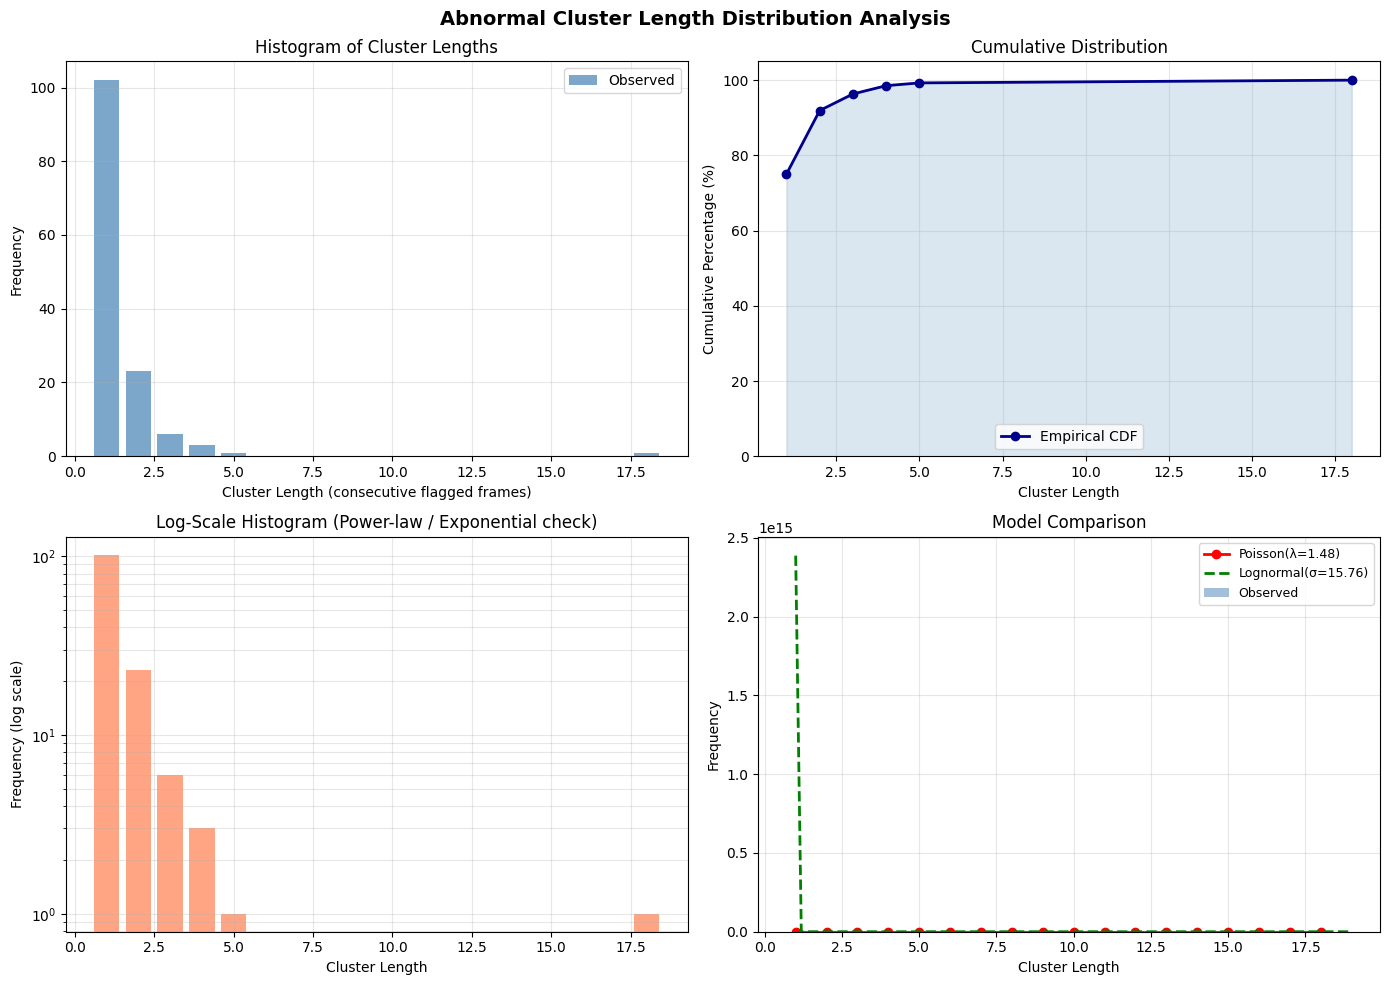


=== Distribution Model Fits ===
Poisson(λ=1.478)
Lognormal(σ=15.759, scale=0.000)
Gamma(α=0.114, scale=2.855)


In [17]:
## Cluster Length Frequency Analysis and Distribution Modeling

if len(all_cluster_lengths) > 0:
    cluster_array = np.array(all_cluster_lengths)
    
    # Compute frequency distribution
    unique_lengths, counts = np.unique(cluster_array, return_counts=True)
    freq_dict = dict(zip(unique_lengths, counts))
    
    print(f"\nCluster Length Frequency Distribution:")
    print(f"{'Length':<8} {'Count':<8} {'Percentage':<12} {'Cumulative %':<12}")
    print("-" * 40)
    cumulative = 0
    for length in sorted(freq_dict.keys()):
        count = freq_dict[length]
        pct = (count / len(all_cluster_lengths)) * 100
        cumulative += pct
        print(f"{length:<8} {count:<8} {pct:>10.2f}% {cumulative:>10.2f}%")
    
    # Statistical summary
    print(f"\nStatistical Summary:")
    print(f"  Total clusters: {len(all_cluster_lengths)}")
    print(f"  Mean cluster length: {np.mean(cluster_array):.3f}")
    print(f"  Median cluster length: {np.median(cluster_array):.1f}")
    print(f"  Std dev: {np.std(cluster_array):.3f}")
    print(f"  Min: {cluster_array.min()}, Max: {cluster_array.max()}")
    print(f"  Q1: {np.percentile(cluster_array, 25):.1f}")
    print(f"  Q3: {np.percentile(cluster_array, 75):.1f}")
    
    # Fit distributions
    from scipy.stats import poisson, lognorm, gamma, expon
    
    # Fit Poisson (discrete)
    lambda_poisson = np.mean(cluster_array)
    
    # Fit Lognormal
    shape_ln, loc_ln, scale_ln = lognorm.fit(cluster_array)
    
    # Fit Gamma
    shape_gm, loc_gm, scale_gm = gamma.fit(cluster_array)
    
    # Plot frequency distribution with model overlays
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Abnormal Cluster Length Distribution Analysis', fontsize=14, fontweight='bold')
    
    # Histogram with frequency overlay
    ax = axes[0, 0]
    ax.bar(unique_lengths, counts, width=0.8, alpha=0.7, color='steelblue', label='Observed')
    ax.set_xlabel('Cluster Length (consecutive flagged frames)')
    ax.set_ylabel('Frequency')
    ax.set_title('Histogram of Cluster Lengths')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Cumulative distribution
    ax = axes[0, 1]
    cumsum = np.cumsum(counts) / np.sum(counts) * 100
    ax.plot(unique_lengths, cumsum, 'o-', color='darkblue', linewidth=2, markersize=6, label='Empirical CDF')
    ax.fill_between(unique_lengths, 0, cumsum, alpha=0.2, color='steelblue')
    ax.set_xlabel('Cluster Length')
    ax.set_ylabel('Cumulative Percentage (%)')
    ax.set_title('Cumulative Distribution')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_ylim(0, 105)
    
    # Log-scale histogram (to check if power-law or exponential)
    ax = axes[1, 0]
    ax.bar(unique_lengths, counts, width=0.8, alpha=0.7, color='coral', log=True)
    ax.set_xlabel('Cluster Length')
    ax.set_ylabel('Frequency (log scale)')
    ax.set_title('Log-Scale Histogram (Power-law / Exponential check)')
    ax.grid(True, alpha=0.3, which='both')
    
    # Q-Q plots or distribution comparison
    ax = axes[1, 1]
    
    # Normalize counts for comparison
    x_range = np.linspace(1, cluster_array.max() + 1, 100)
    
    # Poisson PMF
    poisson_pmf = poisson.pmf(np.arange(1, max(unique_lengths)+1), lambda_poisson) * len(all_cluster_lengths)
    ax.bar(unique_lengths, counts, width=0.6, alpha=0.5, label='Observed', color='steelblue')
    ax.plot(np.arange(1, max(unique_lengths)+1), poisson_pmf, 'o-', label=f'Poisson(λ={lambda_poisson:.2f})', color='red', linewidth=2)
    
    # Lognormal PDF overlay
    lognorm_pdf = lognorm.pdf(x_range, shape_ln, loc_ln, scale_ln) * len(all_cluster_lengths) * (x_range[1] - x_range[0])
    ax.plot(x_range, lognorm_pdf, '--', label=f'Lognormal(σ={shape_ln:.2f})', color='green', linewidth=2)
    
    ax.set_xlabel('Cluster Length')
    ax.set_ylabel('Frequency')
    ax.set_title('Model Comparison')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Model comparison summary
    print(f"\n=== Distribution Model Fits ===")
    print(f"Poisson(λ={lambda_poisson:.3f})")
    print(f"Lognormal(σ={shape_ln:.3f}, scale={scale_ln:.3f})")
    print(f"Gamma(α={shape_gm:.3f}, scale={scale_gm:.3f})")
else:
    print("No abnormal clusters found in corpus.")


=== Top 10 Files with Most Abnormal Frames ===

                                File  Total Flagged Frames  Left Clusters  Right Clusters  Avg Cluster Length  Max Cluster Length
                            manual-2                    20              1               2            6.666667                  17
4ba16f06-b244-4828-afe1-0d32116d5339                     4              2               2            1.000000                   1
ff526205-2756-456f-b24f-940270860e62                     3              3               0            1.000000                   1
acf7a090-7ece-488a-a6e8-f4df878629a9                     3              1               2            1.000000                   1
a354b59a-f460-4226-8dc4-24ecdd548230                     2              0               2            1.000000                   1
                            manual-0                     2              0               1            2.000000                   2
89abb1f9-9daf-48bd-96cd-b0c4afdfa311     

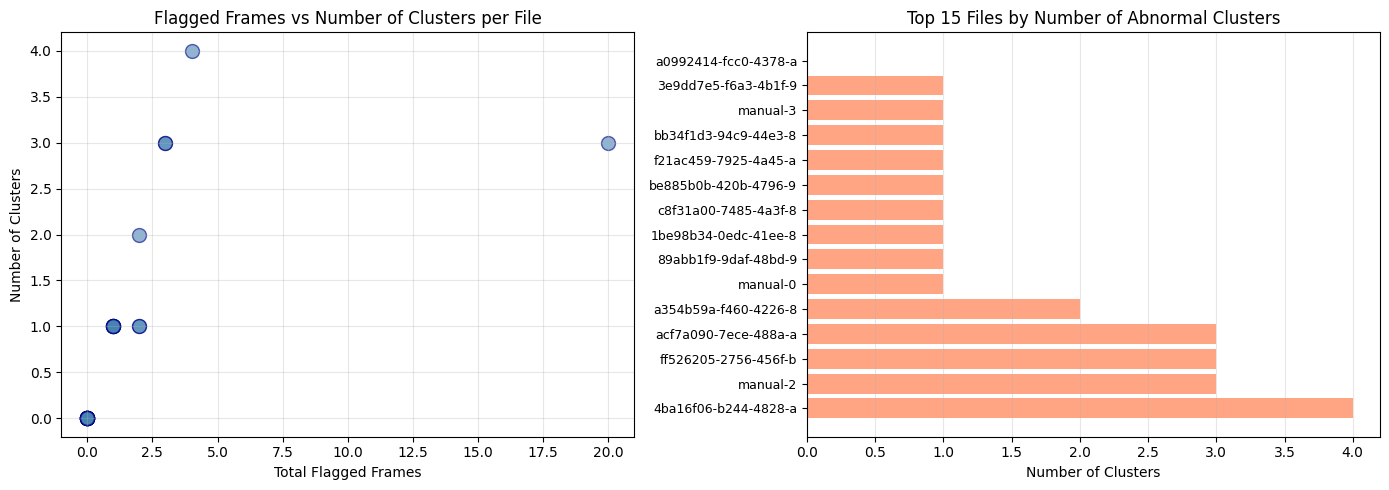

In [12]:
## Per-File Cluster Summary

import pandas as pd

# Build summary dataframe
summary_data = []
for fname, result in corpus_results.items():
    # Handle both old and new data structures
    filepath = result.get('filepath', None)
    if filepath is None:
        # Try to reconstruct from validator
        filepath = "Path not available (re-run clustering cell to update)"
    
    summary_data.append({
        'File': fname,
        'Filepath': filepath,
        'Left Flagged Frames': len(result['left_flagged_frames']),
        'Right Flagged Frames': len(result['right_flagged_frames']),
        'Left Clusters': len(result['left_cluster_lengths']),
        'Right Clusters': len(result['right_cluster_lengths']),
        'Total Clusters': result['total_clusters'],
        'Left Cluster Lengths': result['left_cluster_lengths'],
        'Right Cluster Lengths': result['right_cluster_lengths'],
        'Avg Cluster Length': np.mean(result['left_cluster_lengths'] + result['right_cluster_lengths']) if result['total_clusters'] > 0 else 0,
        'Max Cluster Length': max(result['left_cluster_lengths'] + result['right_cluster_lengths']) if result['total_clusters'] > 0 else 0,
    })

summary_df = pd.DataFrame(summary_data)

# Sort by total flagged frames
summary_df['Total Flagged Frames'] = summary_df['Left Flagged Frames'] + summary_df['Right Flagged Frames']
summary_df = summary_df.sort_values('Total Flagged Frames', ascending=False)

print("\n=== Top 10 Files with Most Abnormal Frames ===\n")
display_cols = ['File', 'Total Flagged Frames', 'Left Clusters', 'Right Clusters', 'Avg Cluster Length', 'Max Cluster Length']
print(summary_df[display_cols].head(10).to_string(index=False))

print(f"\n\nSummary Statistics (Per-File Averages):")
print(f"  Mean total flagged frames per file: {summary_df['Total Flagged Frames'].mean():.2f}")
print(f"  Mean clusters per file: {summary_df['Total Clusters'].mean():.2f}")
print(f"  Mean cluster length (per file): {summary_df['Avg Cluster Length'].mean():.2f}")
print(f"  Max cluster length found: {summary_df['Max Cluster Length'].max():.0f}")
print(f"  Files with clusters: {(summary_df['Total Clusters'] > 0).sum()} / {len(summary_df)}")

# Box plot comparison of cluster lengths by file tier
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: flagged frames vs clusters
ax = axes[0]
ax.scatter(summary_df['Total Flagged Frames'], summary_df['Total Clusters'], 
          alpha=0.6, s=100, color='steelblue', edgecolors='navy')
ax.set_xlabel('Total Flagged Frames')
ax.set_ylabel('Number of Clusters')
ax.set_title('Flagged Frames vs Number of Clusters per File')
ax.grid(True, alpha=0.3)

# Bar: top 15 files by cluster count
ax = axes[1]
top_15 = summary_df.nlargest(15, 'Total Clusters')
ax.barh(range(len(top_15)), top_15['Total Clusters'], color='coral', alpha=0.7)
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels([f.replace('.json', '')[:20] for f in top_15['File']], fontsize=9)
ax.set_xlabel('Number of Clusters')
ax.set_title('Top 15 Files by Number of Abnormal Clusters')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()